In [1]:
%run SSRtransforms_updated.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt

In [2]:
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML" 
# workspace = "/workspace/alvin/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [3]:
def read_mstar_clutter(filepath):
    with open(filepath, 'rb') as f:
        raw = f.read()
    
    header_length = int(raw[:2000].decode('ascii', errors='ignore')
                        .split('PhoenixHeaderLength=')[1].split()[0])
    header = raw[:header_length].decode('ascii', errors='ignore')
    lines = header.splitlines()
    
    def get_field(name):
        return [l for l in lines if name in l][0].split('=')[1].strip()
    
    rows = int(get_field('NumberOfRows'))
    cols = int(get_field('NumberOfColumns'))
    native_header_length = int(get_field('native_header_length'))  # = 512
    
    # data starts at phlen + nhlen, not just phlen
    data_offset = header_length + native_header_length
    
    data = np.frombuffer(raw[data_offset:], dtype='>u2')
    magnitude = data[:rows*cols].reshape(rows, cols).astype(np.float32)
    
    return magnitude

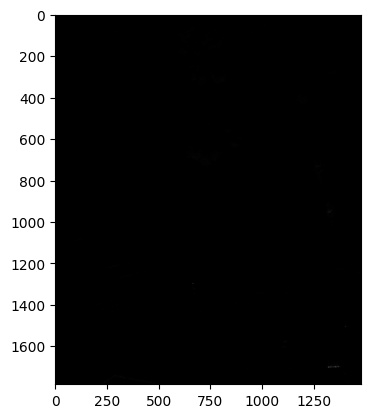

In [4]:
plt.imshow(read_mstar_clutter(
    os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG/HB06277")
), cmap='gray')

In [5]:
log_mapper = LogMapping(c = 1000.0)

In [6]:
test_clutter = read_mstar_clutter(
        os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG/HB06158")
)

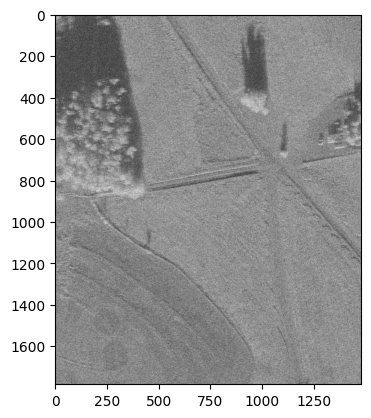

In [7]:
plt.imshow(log_mapper(test_clutter), cmap = "gray")

In [8]:
test_clutter_clipped = np.clip(test_clutter, 0, np.percentile(test_clutter, 95))

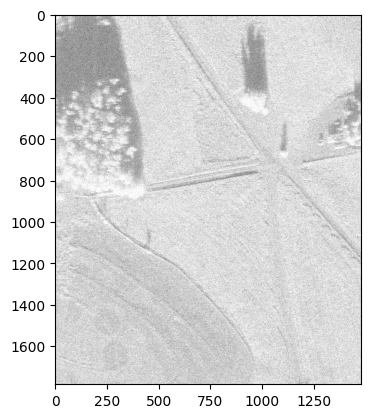

In [9]:
plt.imshow(log_mapper(test_clutter_clipped), cmap = "gray")

In [10]:
clutter_files = [os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG", f) for f in sorted(
    os.listdir(os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG"))) ]

In [11]:
def random_clutter_crop(clutter_image, crop_size=128, 
                         zero_threshold=0.9, shadow_threshold=0.3,
                         max_attempts=100):
    H, W = clutter_image.shape
    for _ in range(max_attempts):
        r = np.random.randint(0, H - crop_size)
        c = np.random.randint(0, W - crop_size)
        crop = clutter_image[r:r+crop_size, c:c+crop_size]
        # reject dead zones
        if (crop > 0).mean() < zero_threshold:
            continue
        # reject shadow-dominated regions (too many low value pixels)
        if (crop < np.percentile(clutter_image, 25)).mean() > shadow_threshold:
            continue
        return crop
    raise ValueError("Could not find valid clutter crop")

In [ ]:
class Scenario2Dataset(torch.utils.data.Dataset):
    def __init__(self, meas_ds, clutter_dir, transform=None):
        self.meas_ds = meas_ds  # applies LogMapping only, no NumpyToTensor3Channel
        self.clutter_files = [
            os.path.join(clutter_dir, f) 
            for f in os.listdir(clutter_dir)
        ]
        self.transform = transform  # NumpyToTensor3Channel
    
    def __len__(self):
        return len(self.meas_ds)
    
    def __getitem__(self, idx):
        # meas_ds returns ((image, filepath), label) due to DatasetFolderWithPath
        (I_meas, filepath), label = self.meas_ds[idx]
        
        # randomly pick clutter file and crop
        clutter_file = random.choice(self.clutter_files)
        C_full = read_mstar_clutter(clutter_file)
        C_full_log = log_mapper(C_full)
        C = random_clutter_crop(C_full_log, crop_size=128)
        
        # merge using Choi segmentation
        M_target, M_shadow, M_clutter = choi_segmentation(I_meas)
        C_bar = (C * M_clutter).sum() / (M_clutter.sum())
        I_meas_bar = (I_meas * M_clutter).sum() / (M_clutter.sum())
        d = C_bar - I_meas_bar
        I_merged = (I_meas + d) * M_target + I_meas * M_shadow + C * M_clutter
        I_merged = I_merged.astype(np.float32)
        
        if self.transform:
            I_merged = self.transform(I_merged)
        
        return I_merged, label

In [12]:
r_clutter = random.choices(clutter_files, k = 1385)

In [13]:
clutter_crop_ls = []
for clutter_file in tqdm(r_clutter, desc = "Cropping clutter"):
    C_full = read_mstar_clutter(clutter_file)
    # C_full_clipped = np.clip(C_full, 0, np.percentile(C_full, 95))
    C_full_log = log_mapper(C_full)
    C = random_clutter_crop(C_full_log)
    clutter_crop_ls.append(C)

Cropping clutter: 100%|█████████████████████████████████████████████████████████████| 1385/1385 [01:51<00:00, 12.47it/s]


In [14]:
meas_ds_s2 = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform=transforms.Compose([Magnitude(), LogMapping(c=1000.0)]),
    loader=mat_file_loader
)

In [15]:
t_mask, s_mask, c_mask = choi_segmentation(meas_ds_s2[0][0][0])

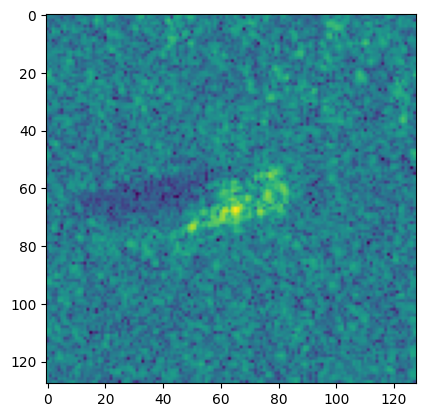

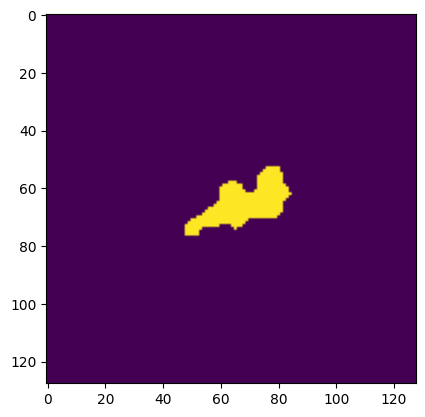

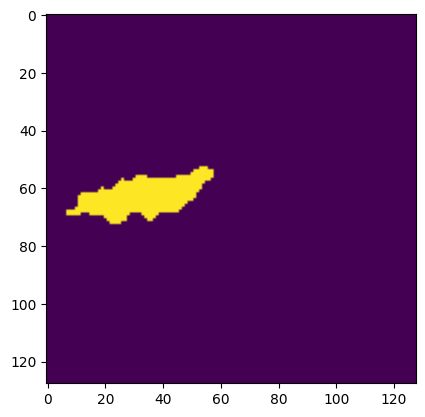

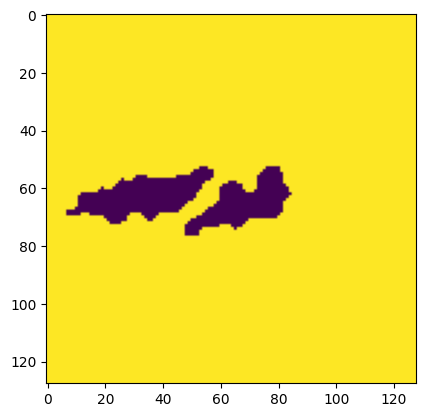

In [16]:
plt.imshow(meas_ds_s2[0][0][0])
plt.show()
plt.imshow(t_mask)
plt.show()
plt.imshow(s_mask)
plt.show()
plt.imshow(c_mask)
plt.show()

In [19]:
C = clutter_crop_ls[0]
I_meas = meas_ds_s2[0][0][0]
M_target, M_shadow, M_clutter = t_mask, s_mask, c_mask 

C_bar = (C * M_clutter).sum() / (M_clutter.sum())
I_meas_bar = (I_meas * M_clutter).sum() / (M_clutter.sum())
d = C_bar - I_meas_bar
# I_merged = (I_meas + d) * M_target + I_meas * M_shadow + C * M_clutter
I_merged = (I_meas + d) * (M_target + M_shadow) + C * M_clutter
I_merged = I_merged.astype(np.float32)

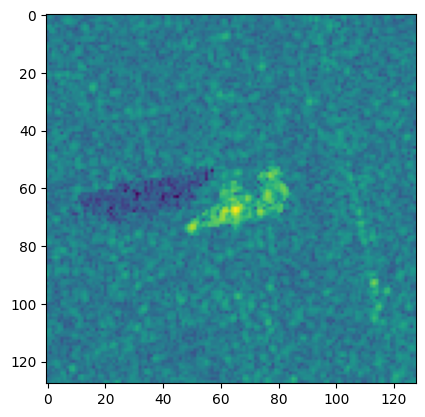

In [20]:
plt.imshow(I_merged)
plt.show()